# Panoramic Image Stitching Pipeline
## HW2: Computer Vision - 4-Step Feature Detection

### Pipeline Overview:
1. **Harris Corner Detection** - Detect interest points
2. **Feature Descriptor Extraction** - Create feature vectors
3. **Feature Matching** - Find correspondences
4. **Image Alignment (RANSAC)** - Estimate transformation and stitch

In [9]:
# Import required libraries
import numpy as np
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

# Import our pipeline classes
from harris_detector import HarrisDetector
from nms_suppressor import NMSSuppressor
from feature_descriptor import FeatureDescriptor
from feature_matcher import FeatureMatcher
from advanced_stitcher import AdvancedStitcher

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

## Load Images

Found 4 images:
  - images/tajm\tajm1.jpg
  - images/tajm\tajm2.jpg
  - images/tajm\tajm3.jpg
  - images/tajm\tajm4.jpg

Processing first 2 images:
  Image 1 shape: (1518, 1267)
  Image 2 shape: (1518, 854)


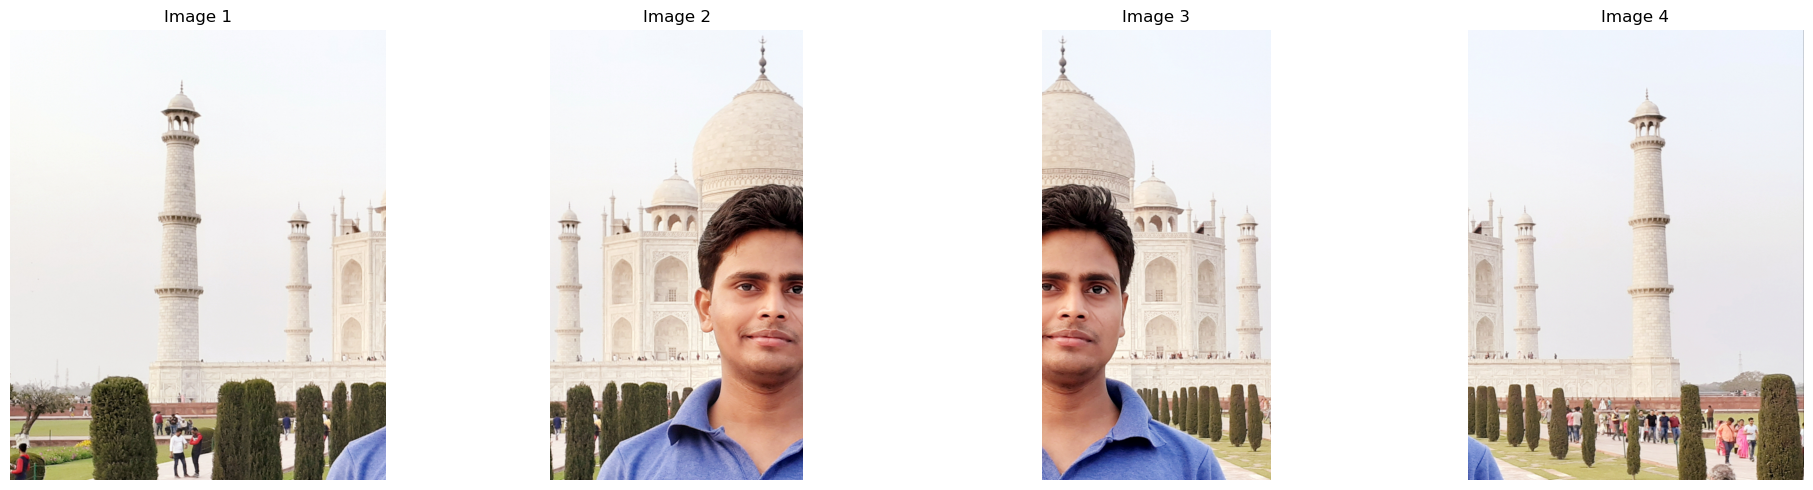

In [ ]:
# Configuration
INPUT_FOLDER = "images/tajm"
OUTPUT_FOLDER = "output/tajm"

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Load images
image_files = sorted(glob.glob(os.path.join(INPUT_FOLDER, '*.*')))
image_files = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(image_files)} images:")
for f in image_files:
    print(f"  - {f}")

# Load first two images - keep in color for display, grayscale for processing
if len(image_files) >= 2:
    im1_color = np.array(Image.open(image_files[0]))
    im2_color = np.array(Image.open(image_files[1]))
    
    # Convert to grayscale for processing
    im1 = np.array(Image.open(image_files[0]).convert('L'))
    im2 = np.array(Image.open(image_files[1]).convert('L'))
    
    print(f"\nProcessing first 2 images:")
    print(f"  Image 1 shape: {im1.shape}")
    print(f"  Image 2 shape: {im2.shape}")
    
    # Display all available images in a grid
    num_images = len(image_files)
    cols = min(4, num_images)  # Max 4 columns
    rows = (num_images + cols - 1) // cols  # Calculate rows needed
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if num_images == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_file in enumerate(image_files):
        row = idx // cols
        col = idx % cols
        img = np.array(Image.open(img_file))
        
        if rows == 1:
            ax = axes[0, col] if cols > 1 else axes[0]
        else:
            ax = axes[row, col]
        
        ax.imshow(img)
        ax.set_title(f'Image {idx+1}')
        ax.axis('off')
    
    # Hide extra subplots if any
    for idx in range(num_images, rows * cols):
        row = idx // cols
        col = idx % cols
        if rows == 1:
            axes[0, col].axis('off')
        else:
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"\nError: Need at least 2 images in '{INPUT_FOLDER}' folder")


## Step 1: Harris Corner Detection

Detecting Harris corners...
Image 1: 860 corners detected
Image 2: 522 corners detected
Image 3: 487 corners detected
Image 4: 766 corners detected


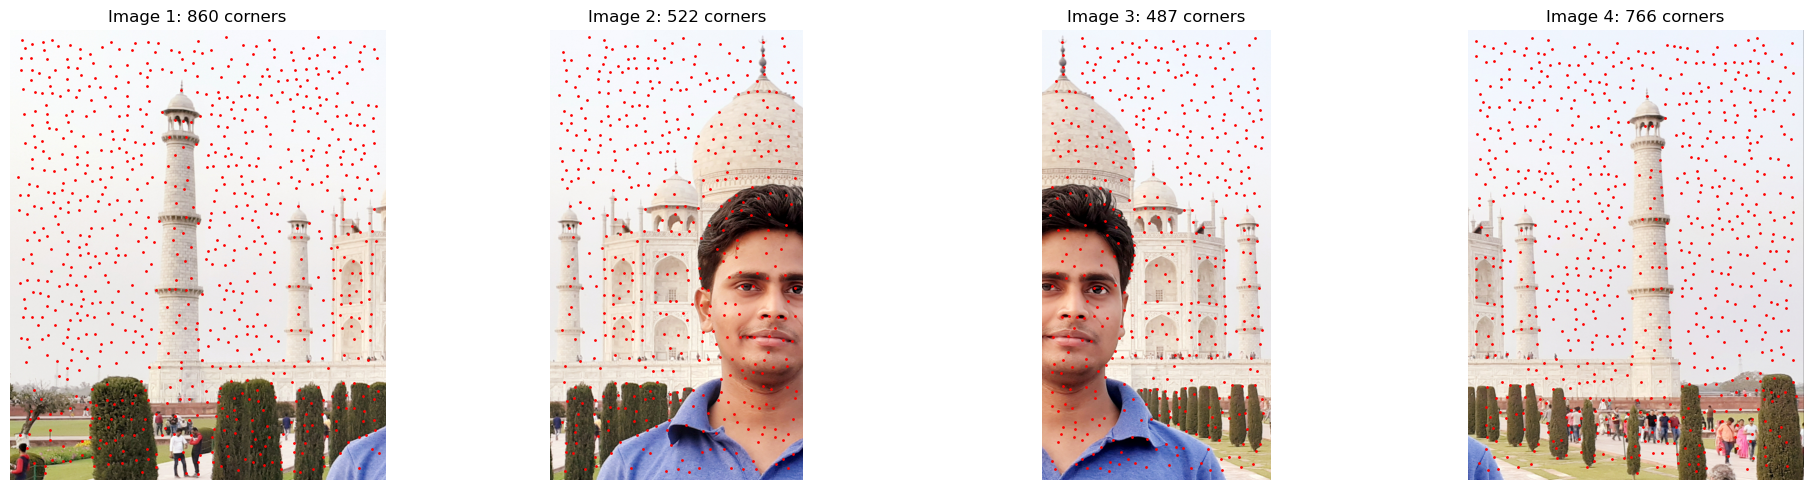


✓ Step 1 complete! Detected corners in 4 images.


In [11]:
# Initialize Harris Detector
harris_detector = HarrisDetector(edge_discard=20, min_distance=20, sigma=1)

# Detect corners in all images
print("Detecting Harris corners...")
all_harris = []
all_coords = []
all_images_gray = []
all_images_color = []

for idx, img_file in enumerate(image_files):
    img_color = np.array(Image.open(img_file))
    img_gray = np.array(Image.open(img_file).convert('L'))
    
    h, coords = harris_detector.detect_corners(img_gray)
    all_harris.append(h)
    all_coords.append(coords)
    all_images_gray.append(img_gray)
    all_images_color.append(img_color)
    
    print(f"Image {idx+1}: {coords.shape[1]} corners detected")

# Visualize detected corners on colored images
num_images = len(image_files)
cols = min(4, num_images)
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
if num_images == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_images):
    row = idx // cols
    col = idx % cols
    ax = axes[row, col]
    
    ax.imshow(all_images_color[idx])
    ax.plot(all_coords[idx][1], all_coords[idx][0], 'ro', markersize=2, markeredgewidth=0)
    ax.set_title(f'Image {idx+1}: {all_coords[idx].shape[1]} corners')
    ax.axis('off')

# Hide extra subplots
for idx in range(num_images, rows * cols):
    row = idx // cols
    col = idx % cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'step1_harris_corners.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Step 1 complete! Detected corners in {num_images} images.")

## Step 2: Non-Maximal Suppression (NMS)

Applying Non-Maximal Suppression...
Image 1: 860 -> 250 corners (after NMS)
Image 2: 522 -> 250 corners (after NMS)
Image 3: 487 -> 250 corners (after NMS)
Image 4: 766 -> 250 corners (after NMS)
Window size used: 11x11


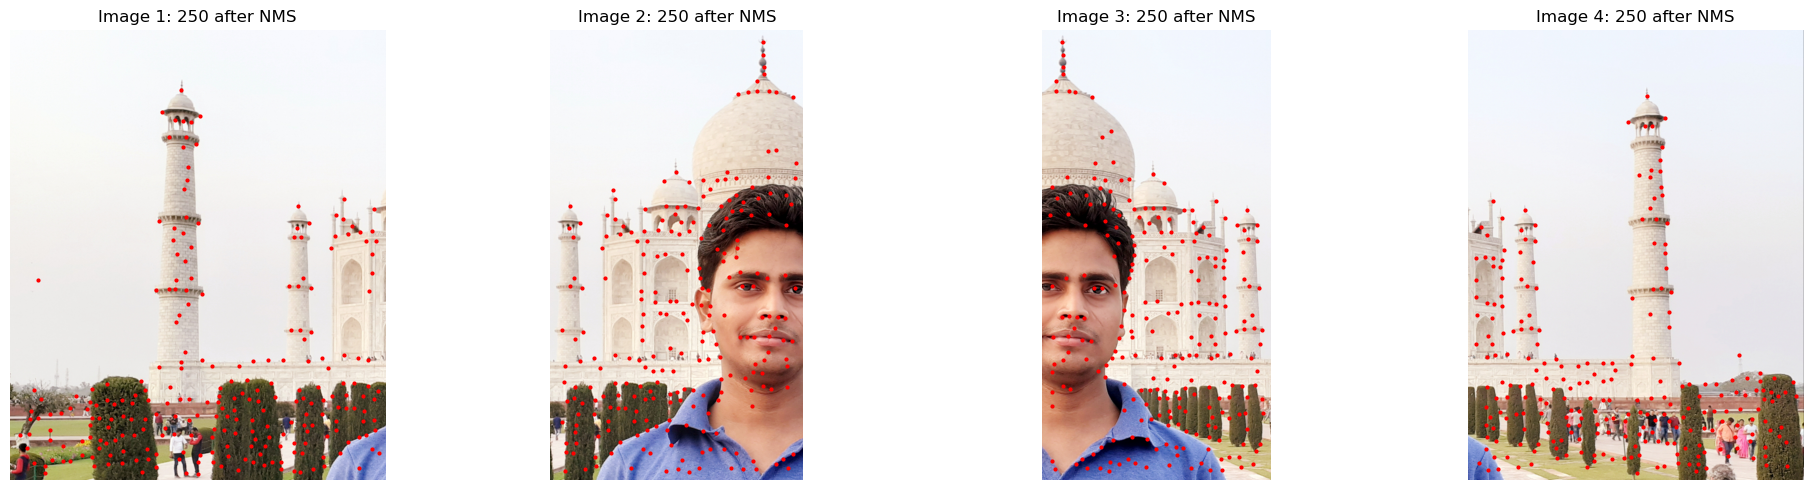


✓ Step 2 complete! NMS applied to 4 images.


In [12]:
# Initialize NMS Suppressor
# Window size controls how far apart corners must be
# Larger window = fewer, more spread out corners
nms_suppressor = NMSSuppressor(window_size=11, max_corners=250)

# Apply NMS to all images
print("Applying Non-Maximal Suppression...")
all_coords_nms = []

for idx in range(num_images):
    coords_nms = nms_suppressor.suppress(all_harris[idx], all_coords[idx])
    all_coords_nms.append(coords_nms)
    print(f"Image {idx+1}: {all_coords[idx].shape[1]} -> {coords_nms.shape[1]} corners (after NMS)")

print(f"Window size used: {nms_suppressor.window_size}x{nms_suppressor.window_size}")

# Visualize NMS results
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
if num_images == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_images):
    row = idx // cols
    col = idx % cols
    ax = axes[row, col]
    
    ax.imshow(all_images_color[idx])
    ax.plot(all_coords_nms[idx][1], all_coords_nms[idx][0], 'ro', markersize=3, markeredgewidth=0)
    ax.set_title(f'Image {idx+1}: {all_coords_nms[idx].shape[1]} after NMS')
    ax.axis('off')

# Hide extra subplots
for idx in range(num_images, rows * cols):
    row = idx // cols
    col = idx % cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'step2_nms_corners.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Step 2 complete! NMS applied to {num_images} images.")

## Step 3: Feature Descriptor Extraction

Extracting feature descriptors...
Image 1: 250 descriptors extracted (shape: (250, 192))
Image 2: 250 descriptors extracted (shape: (250, 192))
Image 3: 250 descriptors extracted (shape: (250, 192))
Image 4: 250 descriptors extracted (shape: (250, 192))


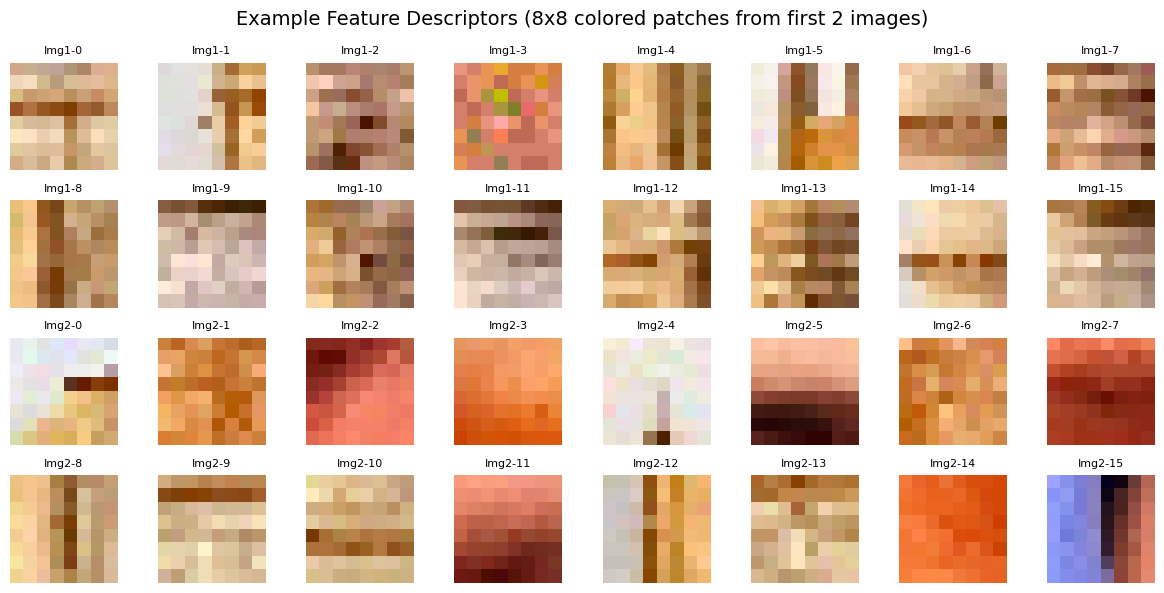


✓ Step 3 complete! Extracted descriptors from 4 images.


In [13]:
# Initialize Feature Descriptor
feature_descriptor = FeatureDescriptor(patch_size=40, descriptor_size=8)

# Extract descriptors from NMS corners using COLOR images
print("Extracting feature descriptors...")
all_descriptors = []
all_valid_coords = []

for idx in range(num_images):
    desc, valid_coords = feature_descriptor.extract_descriptors(
        all_images_color[idx], all_coords_nms[idx]
    )
    all_descriptors.append(desc)
    all_valid_coords.append(valid_coords)
    print(f"Image {idx+1}: {desc.shape[0]} descriptors extracted (shape: {desc.shape})")

# Visualize example descriptors from first two images
if num_images >= 2:
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    fig.suptitle('Example Feature Descriptors (8x8 colored patches from first 2 images)', fontsize=14)
    
    # Show descriptors from image 1 in top two rows
    for idx in range(16):
        row = idx // 8
        col = idx % 8
        
        if idx < all_descriptors[0].shape[0]:
            descriptor = all_descriptors[0][idx].reshape(8, 8, 3)
            desc_display = (descriptor - descriptor.min()) / (descriptor.max() - descriptor.min() + 1e-8)
            axes[row, col].imshow(desc_display)
            axes[row, col].axis('off')
            axes[row, col].set_title(f'Img1-{idx}', fontsize=8)
    
    # Show descriptors from image 2 in bottom two rows
    for idx in range(16):
        row = 2 + idx // 8
        col = idx % 8
        
        if idx < all_descriptors[1].shape[0]:
            descriptor = all_descriptors[1][idx].reshape(8, 8, 3)
            desc_display = (descriptor - descriptor.min()) / (descriptor.max() - descriptor.min() + 1e-8)
            axes[row, col].imshow(desc_display)
            axes[row, col].axis('off')
            axes[row, col].set_title(f'Img2-{idx}', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, 'step3_descriptors.png'), dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n✓ Step 3 complete! Extracted descriptors from {num_images} images.")

## Step 4: Feature Matching

Matching features between consecutive pairs...

Matching Image 1 <-> Image 2...
  Found 96 matches

Matching Image 2 <-> Image 3...
  Found 97 matches

Matching Image 3 <-> Image 4...
  Found 122 matches


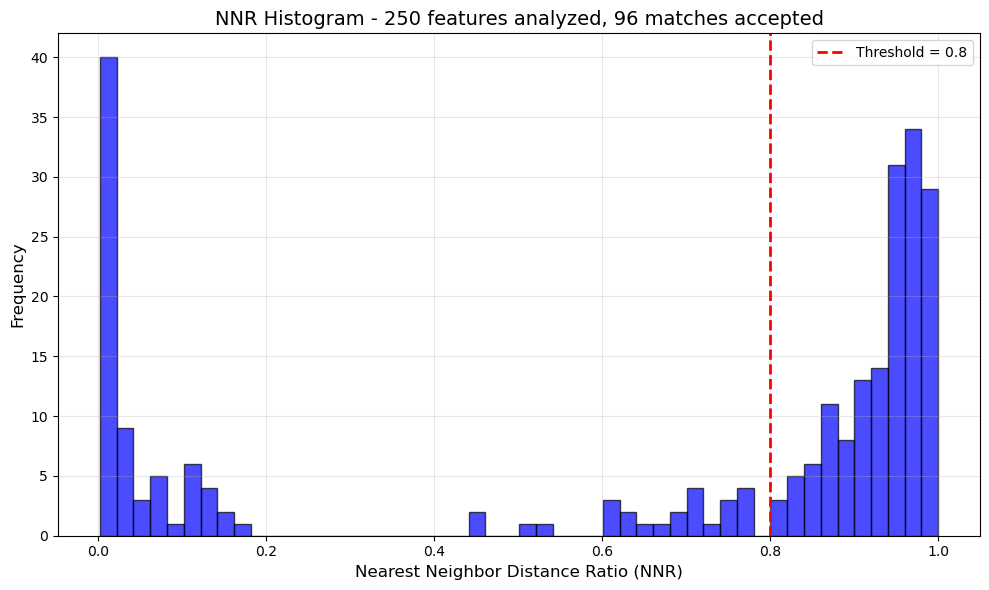

NNR statistics:
  Mean: 0.656
  Median: 0.890
  Matches accepted (ratio < 0.8): 96 / 250 (38.4%)


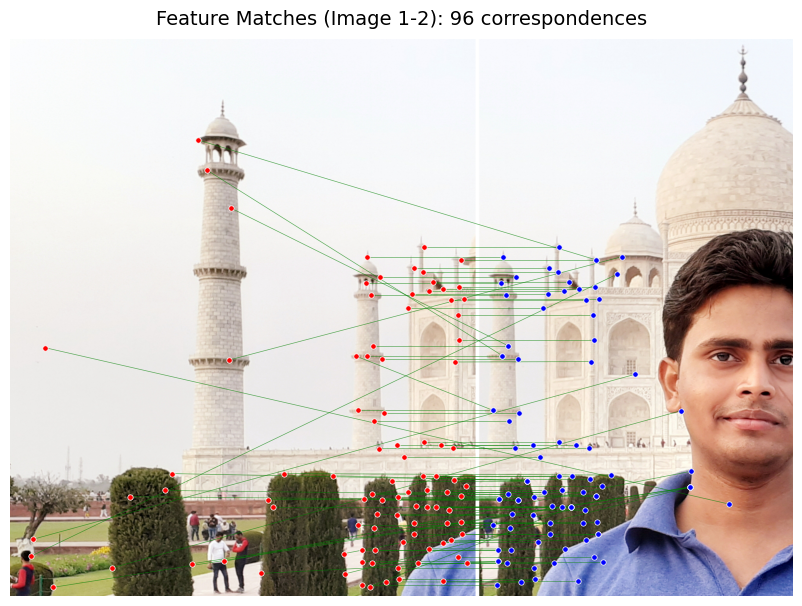

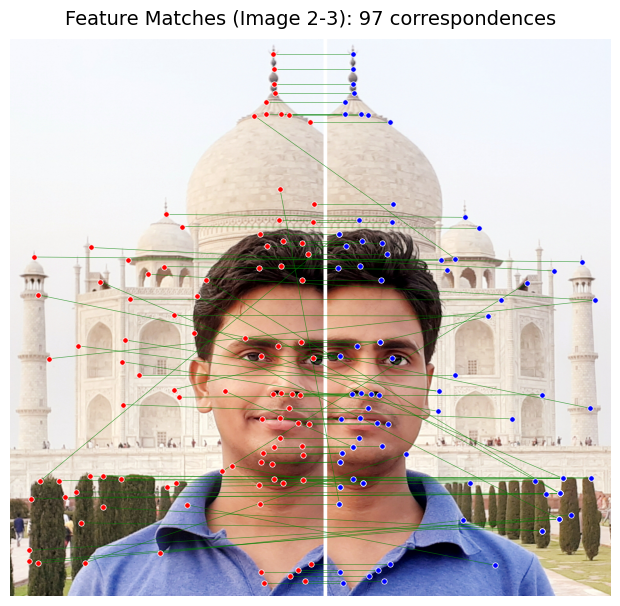

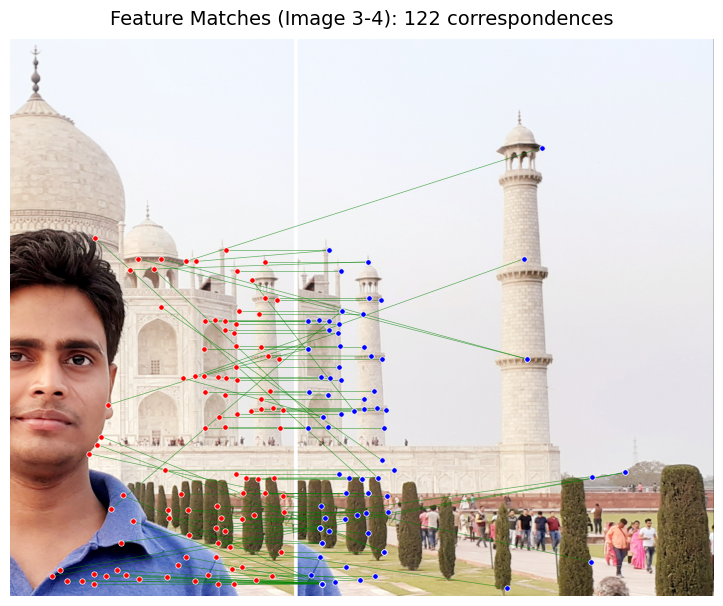


✓ Step 4 complete! Matched and visualized 3 image pairs.


In [20]:
# Initialize Feature Matcher
feature_matcher = FeatureMatcher(threshold_ratio=0.8)

# Match features between consecutive image pairs
print("Matching features between consecutive pairs...")
all_matches = []
all_match_coords = []

for idx in range(num_images - 1):
    print(f"\nMatching Image {idx+1} <-> Image {idx+2}...")
    matches, match_coords1, match_coords2 = feature_matcher.match_features(
        all_descriptors[idx], all_descriptors[idx+1],
        all_valid_coords[idx], all_valid_coords[idx+1]
    )
    all_matches.append(matches)
    all_match_coords.append((match_coords1, match_coords2))
    print(f"  Found {matches.shape[0] if matches.size > 0 else 0} matches")

# Calculate and visualize NNR histogram for first pair
if len(all_matches) > 0 and all_matches[0].size > 0:
    matches = all_matches[0]
    desc1 = all_descriptors[0]
    desc2 = all_descriptors[1]
    # Calculate distance ratios for all features
    from feature_matcher import dist_SSD
    all_ratios = []
    
    for i in range(desc1.shape[0]):
        # Calculate distances to all features in desc2
        distances = dist_SSD(desc1[i:i+1], desc2).flatten()
        # Sort to get nearest and second nearest
        sorted_dist = np.sort(distances)
        if sorted_dist[1] > 0:  # Avoid division by zero
            ratio = sorted_dist[0] / sorted_dist[1]
            all_ratios.append(ratio)
    
    all_ratios = np.array(all_ratios)
    
    # Plot NNR histogram
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(all_ratios, bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label=f'Threshold = 0.8')
    ax.set_xlabel('Nearest Neighbor Distance Ratio (NNR)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'NNR Histogram - {len(all_ratios)} features analyzed, {matches.shape[0]} matches accepted', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, 'step4_nnr_histogram.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"NNR statistics:")
    print(f"  Mean: {np.mean(all_ratios):.3f}")
    print(f"  Median: {np.median(all_ratios):.3f}")
    print(f"  Matches accepted (ratio < 0.8): {matches.shape[0]} / {len(all_ratios)} ({100*matches.shape[0]/len(all_ratios):.1f}%)")

# Visualize matches for ALL consecutive pairs
if len(all_match_coords) > 0:
    for pair_idx in range(len(all_match_coords)):
        match_coords1, match_coords2 = all_match_coords[pair_idx]
        
        if match_coords1.size > 0:
            img1 = all_images_color[pair_idx]
            img2 = all_images_color[pair_idx + 1]
            h1, w1 = img1.shape[:2]
            h2, w2 = img2.shape[:2]
            
            # Create white separator border
            border_width = 10
            separator = np.ones((max(h1, h2), border_width, 3), dtype=img1.dtype) * 255
            
            # Pad images to same height if needed
            if h1 < h2:
                padding = np.zeros((h2 - h1, w1, 3), dtype=img1.dtype)
                img1_padded = np.vstack([img1, padding])
                img2_padded = img2
            elif h2 < h1:
                padding = np.zeros((h1 - h2, w2, 3), dtype=img2.dtype)
                img1_padded = img1
                img2_padded = np.vstack([img2, padding])
            else:
                img1_padded = img1
                img2_padded = img2
            
            # Create combined image with white border
            combined = np.hstack([img1_padded, separator, img2_padded])
            combined_h, combined_w = combined.shape[:2]
            
            # Calculate proper figure size to maintain aspect ratio
            aspect_ratio = combined_w / combined_h
            fig_height = 6
            fig_width = fig_height * aspect_ratio
            
            # Create figure with proper sizing
            fig = plt.figure(figsize=(fig_width, fig_height))
            ax = fig.add_subplot(111)
            ax.imshow(combined)
            
            # Draw matches - coords are [y, x] format
            for i in range(min(match_coords1.shape[1], 100)):  # Limit to 100 matches for clarity
                y1, x1 = match_coords1[0, i], match_coords1[1, i]
                y2, x2 = match_coords2[0, i], match_coords2[1, i]
                
                # For second image, shift x-coordinate by w1 + border_width
                x2_shifted = x2 + w1 + border_width
                
                ax.plot([x1, x2_shifted], [y1, y2], 'g-', linewidth=0.5, alpha=0.6)
                ax.scatter(x1, y1, c='red', s=15, zorder=3, edgecolors='white', linewidths=0.5)
                ax.scatter(x2_shifted, y2, c='blue', s=15, zorder=3, edgecolors='white', linewidths=0.5)
            
            ax.set_title(f'Feature Matches (Image {pair_idx+1}-{pair_idx+2}): {match_coords1.shape[1]} correspondences', fontsize=14, pad=10)
            ax.axis('off')
            plt.tight_layout(pad=0.5)
            plt.savefig(os.path.join(OUTPUT_FOLDER, f'step4_matches_pair_{pair_idx+1}_{pair_idx+2}.png'), dpi=150, bbox_inches='tight', pad_inches=0.1)
            plt.show()
            plt.close()

print(f"\n✓ Step 4 complete! Matched and visualized {num_images-1} image pairs.")

## Step 5: RANSAC Homography & Panorama Creation

Stitching 4 images into panorama...


c:\Users\mohak\Documents\PROJECTS\rgb-img-merging\advanced_stitcher.py:136: RuntimeWarning: divide by zero encountered in divide
  transformed[1, :] / transformed[2, :],
c:\Users\mohak\Documents\PROJECTS\rgb-img-merging\advanced_stitcher.py:137: RuntimeWarning: divide by zero encountered in divide
  transformed[0, :] / transformed[2, :]


Stitching images 3 and 4: 71 inliers
Stitching image 2 with panorama: 47 inliers
Stitching image 1 with panorama: 72 inliers
Panorama shape: (1545, 3222, 3)


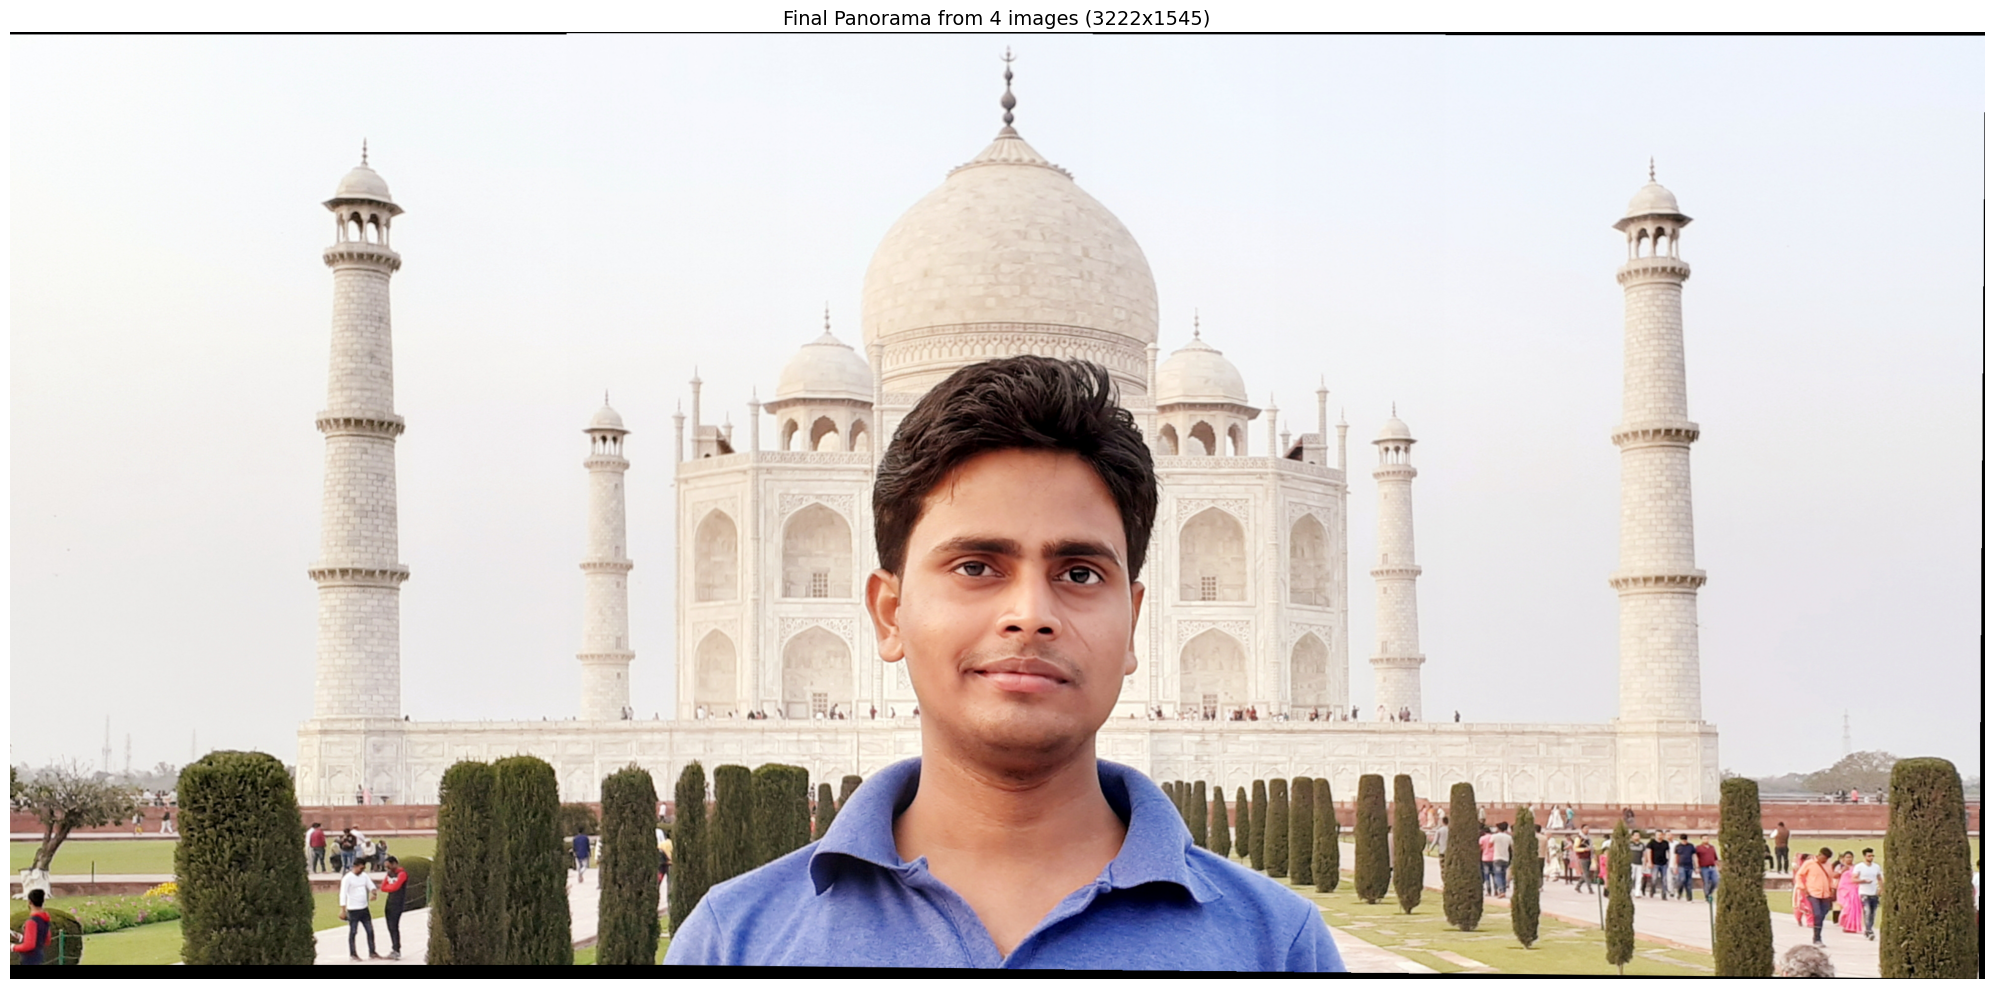


✓ Step 5 complete! Panorama created from 4 images.


In [21]:
# Initialize Advanced Stitcher
advanced_stitcher = AdvancedStitcher(ransac_threshold=5.0, ransac_iterations=1000)

if len(all_match_coords) > 0 and all_match_coords[0][0].size > 0:
    if num_images == 2:
        # For 2 images, use simple homography and panorama creation
        print("Estimating homography with RANSAC...")
        match_coords1, match_coords2 = all_match_coords[0]
        # H should transform img2 to img1, so swap the order
        H, inliers = advanced_stitcher.ransac_homography(match_coords2, match_coords1)
        
        print(f"\nHomography Matrix:")
        print(H)
        print(f"\nInliers: {np.sum(inliers)} out of {len(inliers)} matches ({100*np.sum(inliers)/len(inliers):.1f}%)")
        
        # Visualize inlier matches
        if np.sum(inliers) > 0:
            inlier_coords1 = match_coords1[:, inliers]
            inlier_coords2 = match_coords2[:, inliers]
            
            h1, w1 = all_images_color[0].shape[:2]
            combined = np.hstack([all_images_color[0], all_images_color[1]])
            fig, ax = plt.subplots(figsize=(18, 9))
            ax.imshow(combined)
            
            for i in range(inlier_coords1.shape[1]):
                y1, x1 = inlier_coords1[0, i], inlier_coords1[1, i]
                y2, x2 = inlier_coords2[0, i], inlier_coords2[1, i] + w1
                
                ax.plot([x1, x2], [y1, y2], 'g-', linewidth=0.8, alpha=0.7)
                ax.plot(x1, y1, 'go', markersize=4)
                ax.plot(x2, y2, 'go', markersize=4)
            
            ax.set_title(f'RANSAC Homography Inliers: {np.sum(inliers)} matches')
            ax.axis('off')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_FOLDER, 'step5_ransac_inliers.png'), dpi=150, bbox_inches='tight')
            plt.show()
        
        # Create panorama
        print("\nCreating panorama with alpha blending...")
        panorama = advanced_stitcher.create_panorama(all_images_color[0], all_images_color[1], H)
        
    else:
        # For 3+ images, use multi-image stitching
        print(f"Stitching {num_images} images into panorama...")
        panorama = advanced_stitcher.stitch_multiple_images(all_images_color, all_match_coords)
    
    print(f"Panorama shape: {panorama.shape}")
    
    # Display the panorama
    fig, ax = plt.subplots(figsize=(24, 10))
    ax.imshow(panorama)
    ax.set_title(f'Final Panorama from {num_images} images ({panorama.shape[1]}x{panorama.shape[0]})', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, 'step5_panorama.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save high-resolution panorama
    panorama_pil = Image.fromarray(panorama)
    panorama_pil.save(os.path.join(OUTPUT_FOLDER, 'panorama_final.png'))
    
    print(f"\n✓ Step 5 complete! Panorama created from {num_images} images.")
else:
    print("No matches to estimate transformation!")

In [8]:
print("=" * 60)
print("PANORAMA STITCHING PIPELINE SUMMARY")
print("=" * 60)
print(f"\nTotal images processed: {num_images}")
print(f"\nStep 1 - Harris Corner Detection:")
for idx in range(num_images):
    print(f"  Image {idx+1}: {all_coords[idx].shape[1]} corners")

print(f"\nStep 2 - Non-Maximal Suppression:")
for idx in range(num_images):
    print(f"  Image {idx+1}: {all_coords[idx].shape[1]} -> {all_coords_nms[idx].shape[1]} corners")
print(f"  Window size: {nms_suppressor.window_size}x{nms_suppressor.window_size}")

print(f"\nStep 3 - Feature Descriptor Extraction:")
for idx in range(num_images):
    print(f"  Image {idx+1}: {all_descriptors[idx].shape[0]} descriptors (dim={all_descriptors[idx].shape[1]})")

print(f"\nStep 4 - Feature Matching:")
for idx in range(len(all_matches)):
    print(f"  Pair {idx+1}-{idx+2}: {all_matches[idx].shape[0]} matches")

if len(all_match_coords) > 0 and all_match_coords[0][0].size > 0:
    print(f"\nStep 5 - RANSAC Homography & Panorama:")
    if num_images == 2:
        print(f"  Inliers: {np.sum(inliers)} ({100*np.sum(inliers)/len(inliers):.1f}%)")
        print(f"  Homography matrix (3x3):")
        for row in H:
            print(f"    [{row[0]:8.4f} {row[1]:8.4f} {row[2]:8.4f}]")
    else:
        print(f"  Multi-image stitching: {num_images} images combined")
    print(f"  Panorama size: {panorama.shape[1]} x {panorama.shape[0]} pixels")

print(f"\n" + "=" * 60)
print(f"All results saved to '{OUTPUT_FOLDER}' folder")
print("=" * 60)

PANORAMA STITCHING PIPELINE SUMMARY

Total images processed: 2

Step 1 - Harris Corner Detection:
  Image 1: 4126 corners
  Image 2: 4108 corners

Step 2 - Non-Maximal Suppression:
  Image 1: 4126 -> 250 corners
  Image 2: 4108 -> 250 corners
  Window size: 11x11

Step 3 - Feature Descriptor Extraction:
  Image 1: 250 descriptors (dim=192)
  Image 2: 250 descriptors (dim=192)

Step 4 - Feature Matching:
  Pair 1-2: 169 matches

Step 5 - RANSAC Homography & Panorama:
  Inliers: 102 (60.4%)
  Homography matrix (3x3):
    [  0.7366  -0.3171 703.3968]
    [ -0.0313   0.5953 240.9751]
    [ -0.0000  -0.0001   1.0000]
  Panorama size: 4461 x 2268 pixels

All results saved to 'output' folder
